<a href="https://colab.research.google.com/github/keerthanamjohn3-arch/git.demo/blob/main/KNN_5(framingham)_OverSampling%26UnderSampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Datasets/framingham.csv")
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [ ]:
df.isna().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [ ]:
df['education'].mode()[0]

np.float64(1.0)

In [ ]:
df['cigsPerDay'].mode()[0]


np.float64(0.0)

In [ ]:
df['BPMeds'].mode()[0]


np.float64(0.0)

In [ ]:
df['totChol'].mode()[0]


np.float64(240.0)

In [ ]:
df['BMI'].median()


25.4

In [ ]:
df['heartRate'].mode()[0]


np.float64(75.0)

In [ ]:
df['glucose'].mode()[0]

np.float64(75.0)

In [ ]:
df['education']=df['education'].fillna(df['education'].mode()[0])


In [ ]:
df['cigsPerDay']=df['cigsPerDay'].fillna(df['cigsPerDay'].mode()[0])


In [ ]:
df['BPMeds']=df['BPMeds'].fillna(df['BPMeds'].mode()[0])


In [ ]:
df['totChol']=df['totChol'].fillna(df['totChol'].mode()[0])


In [ ]:
df['BMI']=df['BMI'].fillna(df['BMI'].median())


In [ ]:
df['heartRate']=df['heartRate'].fillna(df['heartRate'].mode()[0])


In [ ]:
df['glucose']=df['glucose'].fillna(df['glucose'].mode()[0])
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,0.0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,75.0,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [ ]:
df.isna().sum()

,0
male,0
age,0
education,0
currentSmoker,0
cigsPerDay,0
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,0


In [ ]:
df.dtypes

,0
male,int64
age,int64
education,float64
currentSmoker,int64
cigsPerDay,float64
BPMeds,float64
prevalentStroke,int64
prevalentHyp,int64
diabetes,int64
totChol,float64


In [ ]:
X = df.iloc[:,:-1].values
X

array([[  1.  ,  39.  ,   4.  , ...,  26.97,  80.  ,  77.  ],
       [  0.  ,  46.  ,   2.  , ...,  28.73,  95.  ,  76.  ],
       [  1.  ,  48.  ,   1.  , ...,  25.34,  75.  ,  70.  ],
       ...,
       [  0.  ,  52.  ,   2.  , ...,  21.47,  80.  , 107.  ],
       [  1.  ,  40.  ,   3.  , ...,  25.6 ,  67.  ,  72.  ],
       [  0.  ,  39.  ,   3.  , ...,  20.91,  85.  ,  80.  ]])

In [ ]:
y = df.iloc[:,-1]
y

,TenYearCHD
0,0
1,0
2,0
3,1
4,0
...,...
4235,0
4236,0
4237,0
4238,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler
Scaler = MinMaxScaler()
Scaler.fit(X)
X_Scaled = Scaler.transform(X)
X_Scaled

array([[1.        , 0.18421053, 1.        , ..., 0.27702375, 0.36363636,
        0.10451977],
       [0.        , 0.36842105, 0.33333333, ..., 0.31968008, 0.51515152,
        0.10169492],
       [1.        , 0.42105263, 0.        , ..., 0.23751818, 0.31313131,
        0.08474576],
       ...,
       [0.        , 0.52631579, 0.33333333, ..., 0.14372273, 0.36363636,
        0.18926554],
       [1.        , 0.21052632, 0.66666667, ..., 0.24381968, 0.23232323,
        0.09039548],
       [0.        , 0.18421053, 0.66666667, ..., 0.13015027, 0.41414141,
        0.11299435]])

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_Scaled,y,test_size = 0.3,random_state = 1)


In [ ]:
X_test.shape,y_test.shape
X_train.shape,y_train.shape


((2968, 15), (2968,))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=13)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=13)

In [ ]:
y_pred = knn.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
y_test.values


array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred)*100)

85.22012578616352


In [ ]:
y_new = knn.predict(Scaler.transform([[78,6,7,6,77,5,32,9,72,44,47,35,2,7,2]]))
if y_new.item()==1:
  print("Person will suffer lung cancer")
else:
  print("Person will not suffer lung cancer")

Person will not suffer lung cancer


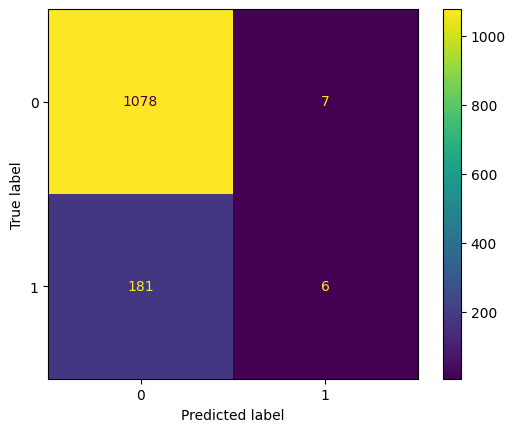

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred,digits = 4))

              precision    recall  f1-score   support

           0     0.8562    0.9935    0.9198      1085
           1     0.4615    0.0321    0.0600       187

    accuracy                         0.8522      1272
   macro avg     0.6589    0.5128    0.4899      1272
weighted avg     0.7982    0.8522    0.7934      1272



In [ ]:
df["TenYearCHD"].value_counts()

,count
TenYearCHD,
0,3596
1,644


**NAIVE BASED** ALGORITHM ON FRAMINGHAM


In [ ]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
nb = GaussianNB()
nb.fit(X_train,y_train)

GaussianNB()

In [ ]:
y_pred = nb.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred)*100)

82.70440251572327


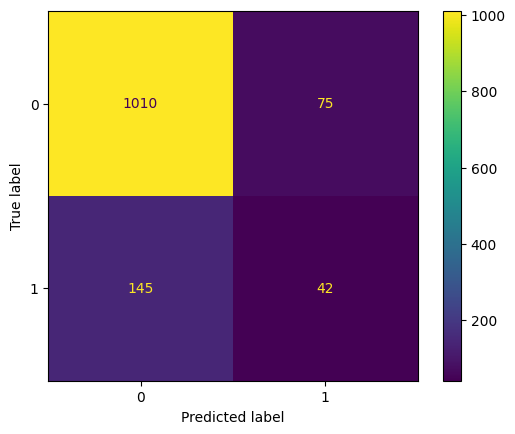

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred,digits = 4))

              precision    recall  f1-score   support

           0     0.8745    0.9309    0.9018      1085
           1     0.3590    0.2246    0.2763       187

    accuracy                         0.8270      1272
   macro avg     0.6167    0.5777    0.5891      1272
weighted avg     0.7987    0.8270    0.8098      1272



Handling imabalanced datasets

OverSampling

In [ ]:
from imblearn.over_sampling import SMOTE
os = SMOTE(random_state = 1)
X_os,y_os = os.fit_resample(X,y)
y_os.value_counts()

,count
TenYearCHD,
0,3596
1,3596


In [ ]:
X_os_scaled = Scaler.fit_transform(X_os)

In [ ]:
X_train_os,X_test_os,y_train_os,y_test_os = train_test_split(X_os,y_os,test_size = 0.3,random_state = 3)

In [ ]:
X_train_os.shape,y_train_os.shape

((5034, 15), (5034,))

In [ ]:
X_test_os.shape,y_train_os.shape

((2158, 15), (5034,))

In [ ]:
nb.fit(X_train_os,y_train_os)
y_pred = nb.predict(X_test_os)
y_pred

array([0, 0, 1, ..., 0, 0, 0])

In [ ]:
print(classification_report(y_test_os,y_pred))

              precision    recall  f1-score   support

           0       0.58      0.88      0.70      1083
           1       0.75      0.37      0.50      1075

    accuracy                           0.62      2158
   macro avg       0.67      0.62      0.60      2158
weighted avg       0.67      0.62      0.60      2158



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train_os,y_train_os)
y_pred_os1 = knn.predict(X_test_os)
y_pred_os1


array([1, 0, 1, ..., 0, 1, 1])

In [ ]:
print(classification_report(y_test_os,y_pred_os1))

              precision    recall  f1-score   support

           0       0.95      0.68      0.79      1083
           1       0.75      0.97      0.84      1075

    accuracy                           0.82      2158
   macro avg       0.85      0.82      0.82      2158
weighted avg       0.85      0.82      0.82      2158



UnderSampling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
us = RandomUnderSampler(random_state = 1)
X_us,y_us = us.fit_resample(X,y)

In [ ]:
y_us.value_counts()

,count
TenYearCHD,
0,644
1,644


In [ ]:
scaler = MinMaxScaler()
X_scaled_us = scaler.fit_transform(X_us)

In [ ]:
X_train_us,X_test_us,y_train_us,y_test_us = train_test_split(X_scaled_us,y_us,test_size = 0.3,random_state = 1)

In [ ]:
knn_us = KNeighborsClassifier()
knn_us.fit(X_train_us,y_train_us)
y_pred_us = knn_us.predict(X_test_us)
y_pred_us

array([0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,

In [ ]:
print(classification_report(y_test_us,y_pred_us))

              precision    recall  f1-score   support

           0       0.61      0.59      0.60       196
           1       0.59      0.61      0.60       191

    accuracy                           0.60       387
   macro avg       0.60      0.60      0.60       387
weighted avg       0.60      0.60      0.60       387



In [ ]:
nb_us = GaussianNB()
nb_us.fit(X_train_us,y_train_us)
y_pred_us1 = nb_us.predict(X_test_us)
y_pred_us1

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
print(classification_report(y_test_us,y_pred_us1))

              precision    recall  f1-score   support

           0       0.54      0.97      0.70       196
           1       0.85      0.15      0.26       191

    accuracy                           0.57       387
   macro avg       0.70      0.56      0.48       387
weighted avg       0.69      0.57      0.48       387

